# Using ES(1+1) 1/5 to find optimal hyperparameters for a regression model to approximate y=-x^2

Hyper parameters to optimize
- number of hidden neurons
- learning rate
- batch size


The following params are fixed
- number of epochs
- loss function
- optimizer algorithm
- activation function


CJ Chung, Oct 2024,

License CC BY 4.0:
The CC BY 4.0 license allows anyone to share, adapt, and use the licensed work for any purpose, as long as they give appropriate credit to the original creator.

In [ ]:
from keras.models import Sequential, save_model, load_model
from keras.layers import Dense, Activation, Input
from keras import optimizers, callbacks
import numpy as np
import matplotlib.pyplot as plt

# Use (n, 1) shape instead of (n,), since (n, 1) is the general input format for Keras DNN models
X = np.linspace(0, 1, 10).reshape(-1,1) # -1 simply means that it is an unknown dimension and we want numpy to figure it out.
y = -X*X
Xt = np.linspace(0, 1, 7).reshape(-1, 1)
yt = -Xt * Xt

NumVar = 3
# num_neurons, lr, bsize

def func_eval(param):
  global m
  m = Sequential([
    Input(shape=(1,)),
    Dense(int(param[0]), activation='relu'),
    Dense(1)
  ])
  m.compile(optimizer=optimizers.SGD(learning_rate=param[1]), loss='mse')
  cb_list = [
    callbacks.EarlyStopping(monitor='val_loss', patience=5,
                            restore_best_weights=True),
  ]
  m.fit(X, y, epochs=400, batch_size=int(param[2]), verbose = 0,
        validation_data=(Xt, yt) , callbacks=cb_list)
  loss = m.evaluate(Xt, yt, verbose=0)
  return loss

In [ ]:
# Constants
MaxGen = 30
MaxTrial = 3

# acceptable range for each hyper parameter
low0 = 4   # number of hidden neurons
high0 = 32
low1 = 0.001 # smallest learning rate
high1 = 1.5
low2  = 4 # min batch size
high2 = 10

In [ ]:
# num_neurons, lr, bsize, epochs
def print_HP_found(x, eval):
  print(f"#neurons={int(x[0])}, lr={x[1]:.3f}, bsize={int(x[2])}")
  print(f"Eval={eval}\n")

In [ ]:
totgen = 0
foundCnt = 0  # acceptable solution found
objfunc = func_eval #
#np.random.seed(1) # makes the random numbers predictable to debug

# for 1/5 rule
stepSize_i = 0.82 # initial stepsize
stepSize_r = 0.82 # stepsize change ratio.
                  # 0.82 was used previously by Hans-Paul Schwefel, a PhD student of Rechenberg

[#neurons, lr, bsize]
************************** Trial # = 1
Acceptable solution found after 3 generations:
#neurons=4, lr=0.056, bsize=4
Eval=0.001666784519329667



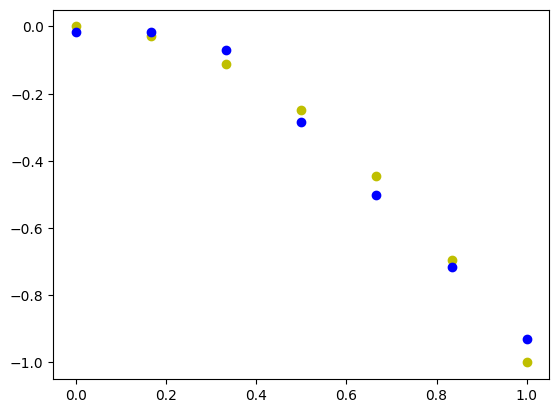

************************** Trial # = 2
Acceptable solution found after 7 generations:
#neurons=4, lr=0.316, bsize=10
Eval=0.0016347834607586265



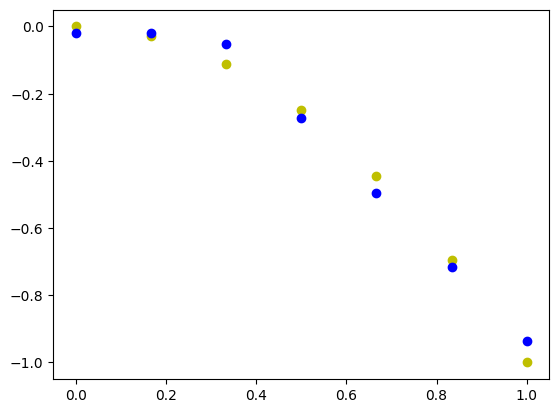

************************** Trial # = 3
Acceptable solution found after 9 generations:
#neurons=18, lr=0.286, bsize=4
Eval=0.0023506470024585724



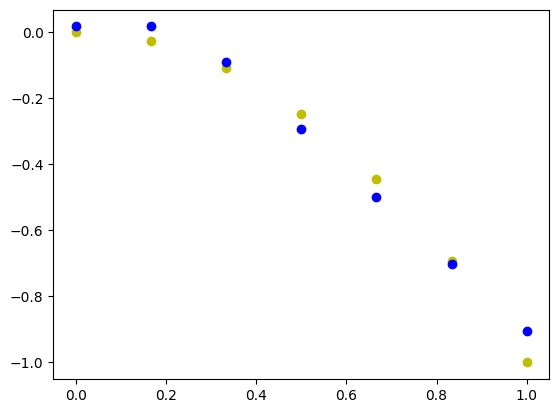


System Success = 100.0%
Avgerage # of generations used = 6


In [ ]:
print(f"[#neurons, lr, bsize]")

for trial in range(0, MaxTrial):
    xp = np.empty(NumVar) # parent
    p_val = 0
    xo = np.empty(NumVar) # offspring
    o_val = 0

    successCnt = 0;
    WindowSize = 5

    print(f"************************** Trial # = {trial+1}")

    # initialize hyper parameters
    xp[0] = 4 # start with the smallest num neurons
    xp[1] = round(np.random.uniform(low1, high1), 2) # init learning rate
    xp[2] = 4 # start with the smallest batch size

    p_val = objfunc(xp)     # evaluate the parent

    stepSize = stepSize_i

    for g in range(1, MaxGen+1):
        if (g % WindowSize) == 0: # update stepsize
            if successCnt > (WindowSize * 0.2):
                stepSize = stepSize / stepSize_r #increase
            elif successCnt < (WindowSize * 0.2):
                stepSize = stepSize * stepSize_r #decrease
            successCnt = 0

        # mutate the num of hidden neurons
        # mu and sigma, a mean of 0 and a standard deviation of stepSize
        xo[0] = xp[0] + round(np.random.normal(0.0, stepSize))*(high0-low0)*0.5
        xo[0] = np.clip(xo[0], low0, high0) # to correct if any variation goes out of acceptable range

        # mutate the learning rate
        xo[1] = xp[1] + round(np.random.normal(0.0, stepSize), 2)*(high1-low1)
        # to correct if any variation goes out of acceptable range
        xo[1] = np.clip(xo[1], low1, high1)

        # mutate the batch size
        xo[2] = xp[2] + round(np.random.normal(0.0, stepSize))*(high2-low2)
        # to correct if any variation goes out of acceptable range
        xo[2] = np.clip(xo[2], low2, high2)

        o_val = objfunc(xo)  # evaluate offspring

        # select
        if o_val < p_val:
            #xp = xo # No! must maintain two separate spaces
            xp = xo.copy()
            p_val = o_val
            successCnt += 1;
            #print(xp, p_val, successCnt, stepSize)

        if p_val < 0.005: # we assume minima is zero.
            print(f"Acceptable solution found after {g} generations:")
            if p_val < best_p_val:
                best_p_val = p_val
                #save_model(m, 'best_minusXsquared.keras')
            totgen += g
            foundCnt += 1
            break # cannot use while since it may not find acceptable minia
        # end of generation
    print_HP_found(xp, p_val)
    plt.plot(Xt, yt, 'yo') # yellow circle
    plt.plot(Xt, m.predict(Xt, verbose=0), 'bo') # blue circles
    plt.show()
    # end of Trial

print(f"\nSystem Success = {foundCnt/MaxTrial*100}%")
totgen += (MaxTrial-foundCnt)*MaxGen
print(f"Avgerage # of generations used = {(totgen/MaxTrial):,.0f}")